# Supermart Grocery Sales — Profit Margin Analysis

## Business Problem
Supermart is a grocery retail chain operating across multiple regions in India.
This analysis aims to identify which product categories and regions generate
the highest profit margins, and what impact discounting has on profitability.

## Dataset
- Source: Supermart Grocery Sales - Retail Analytics Dataset
- Records: 9,994 transactions
- Features: Category, Sub Category, Region, State, Sales, Discount, Profit, Order Date

## Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [21]:
# Load the dataset
df = pd.read_csv("C:/Users/Megha BK/OneDrive/Desktop/Internship/Supermart Grocery Sales - Retail Analytics Dataset.csv")

# Basic overview
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 11)

Columns: ['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State']

First 5 rows:


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


## Data Overview & Cleaning

In [3]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB
None

Missing Values:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

B

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [4]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

# Extract useful time features
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

print("Date column fixed!")
print("\nYear range:", df['Year'].min(), "to", df['Year'].max())
print("New columns added:", ['Month', 'Year', 'Profit Margin'])
df.head()

Date column fixed!

Year range: 2015 to 2018
New columns added: ['Month', 'Year', 'Profit Margin']


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Month,Year,Profit Margin
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu,11,2017,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu,11,2017,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu,6,2017,7.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu,10,2016,10.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu,10,2016,39.0


## Exploratory Data Analysis (EDA)

### 1. Which product category generates the highest profit margin?
We analyse average profit margin across all 7 product categories to identify which categories are most profitable for Supermart.

C:\Users\Megha BK\AppData\Local\Temp\ipykernel_33592\524568790.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_margin.values, y=category_margin.index, palette='viridis')


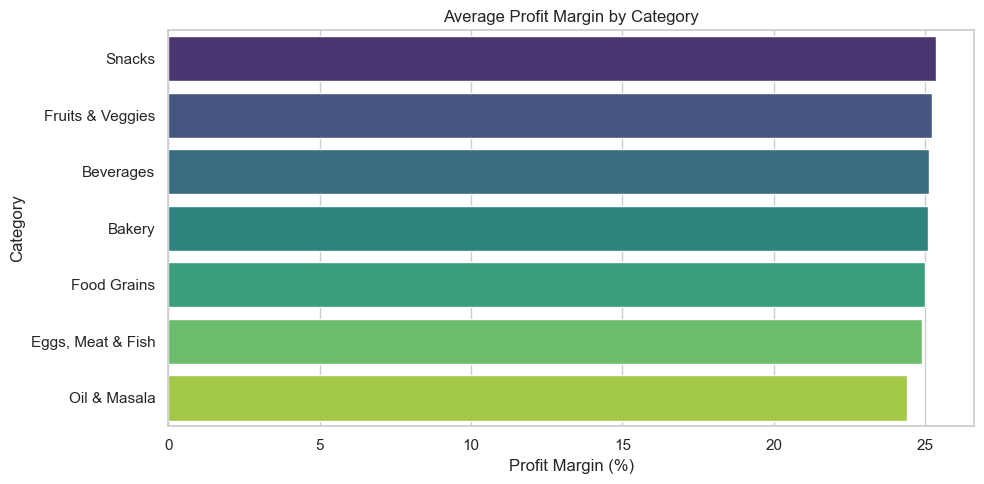

In [5]:
# Profit Margin by Category
plt.figure(figsize=(10, 5))
category_margin = df.groupby('Category')['Profit Margin'].mean().sort_values(ascending=False)
sns.barplot(x=category_margin.values, y=category_margin.index, palette='viridis')
plt.title('Average Profit Margin by Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### 2. Which region is most profitable?
We compare average profit margins across all 5 regions to identify where Supermart performs best geographically.

C:\Users\Megha BK\AppData\Local\Temp\ipykernel_33592\1306164641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_margin.index, y=region_margin.values, palette='coolwarm')


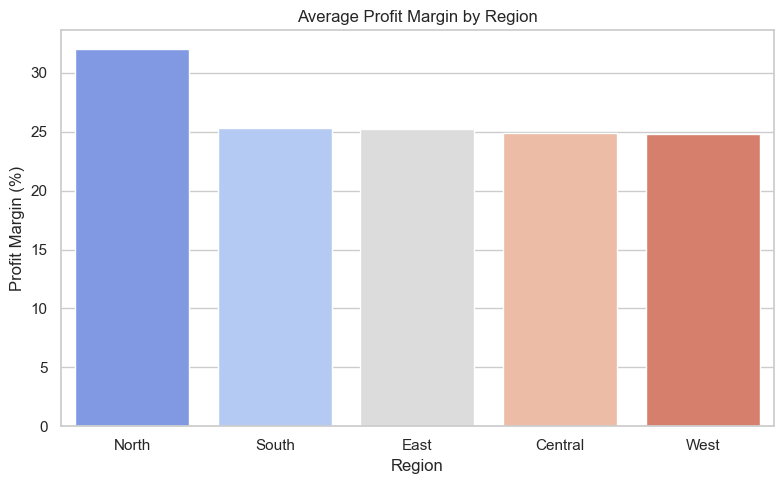

In [6]:
# Profit Margin by Region
plt.figure(figsize=(8, 5))
region_margin = df.groupby('Region')['Profit Margin'].mean().sort_values(ascending=False)
sns.barplot(x=region_margin.index, y=region_margin.values, palette='coolwarm')
plt.title('Average Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

### 3. Does offering higher discounts reduce profit margins?
We examine whether there is a relationship between discount rate and profit margin across all orders.

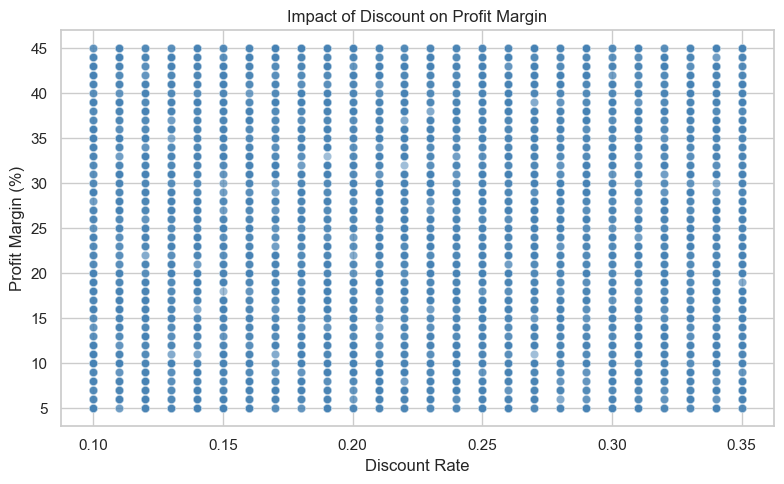

In [7]:
# Impact of Discount on Profit Margin
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit Margin', alpha=0.3, color='steelblue')
plt.title('Impact of Discount on Profit Margin')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

### 4. How have sales grown over time?
We analyse monthly sales totals from 2015 to 2018 to identify growth trends and seasonal patterns.

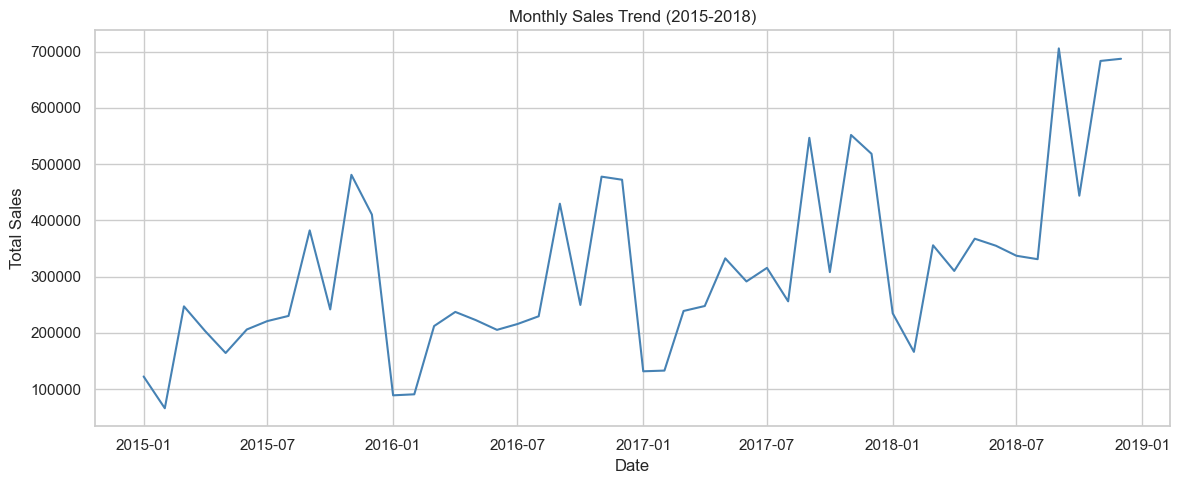

In [8]:
# Sales Trend Over Time
plt.figure(figsize=(12, 5))
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', color='steelblue')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### 5. Which sub-categories generate the most total profit?
We identify the top 10 sub-categories by total profit to pinpoint Supermart's biggest revenue drivers.

C:\Users\Megha BK\AppData\Local\Temp\ipykernel_33592\322557002.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_cat_profit.values, y=sub_cat_profit.index, palette='viridis')


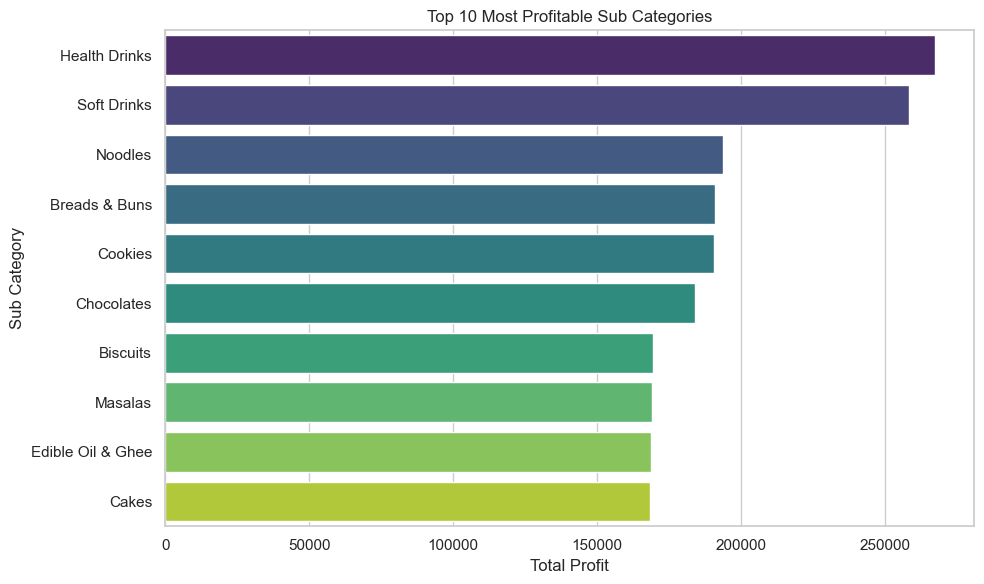

In [9]:
# Top 10 Most Profitable Sub Categories
plt.figure(figsize=(10, 6))
sub_cat_profit = df.groupby('Sub Category')['Profit'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=sub_cat_profit.values, y=sub_cat_profit.index, palette='viridis')
plt.title('Top 10 Most Profitable Sub Categories')
plt.xlabel('Total Profit')
plt.ylabel('Sub Category')
plt.tight_layout()
plt.show()

## Key Insights & Business Recommendations

1. **North region outperforms all others** with a ~32% average profit margin vs ~25% for other regions. Supermart should investigate what drives this and replicate it elsewhere.

2. **Health Drinks and Soft Drinks are the top profit drivers** — together they generate significantly more profit than any other sub-category.

3. **Discounting does not significantly impact profit margins** — margins remain consistent across all discount levels (10%-35%), suggesting the pricing structure absorbs discounts well.

4. **Sales are growing year on year** from 2015 to 2018, with 2018 recording the highest monthly sales peaks — indicating a healthy, scaling business.

5. **All categories have similar profit margins (~25%)** — profitability is driven more by volume and region than by product category.

## Machine Learning — Predicting Profit Margin Class

### Business Question
Can we predict whether a grocery order will generate a high or low profit margin?

### Approach
Orders are classified as:
- **High Profit Margin (1):** Above median profit margin
- **Low Profit Margin (0):** Below median profit margin

In [15]:
from sklearn.preprocessing import LabelEncoder

# Define target — top 25% profit orders vs rest
threshold = df['Profit'].quantile(0.75)
df['Target'] = (df['Profit'] > threshold).astype(int)

print("Profit threshold (75th percentile):", round(threshold, 2))
print("\nClass Distribution:")
print(df['Target'].value_counts())
print("\nClass Balance:")
print(df['Target'].value_counts(normalize=True) * 100)

# Encode categorical features
le = LabelEncoder()
df_ml = df.copy()
for col in ['Category', 'Sub Category', 'Region', 'State']:
    df_ml[col] = le.fit_transform(df_ml[col])

# Define features and target
X = df_ml[['Category', 'Sub Category', 'Region', 'State', 'Sales', 'Discount', 'Month', 'Year']]
y = df_ml['Target']

print("\nFeatures shape:", X.shape)

Profit threshold (75th percentile): 525.63

Class Distribution:
Target
0    7495
1    2499
Name: count, dtype: int64

Class Balance:
Target
0    74.994997
1    25.005003
Name: proportion, dtype: float64

Features shape: (9994, 8)


## Model Training & Evaluation

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} — Accuracy: {round(acc*100, 2)}%")
    print(classification_report(y_test, y_pred))


Logistic Regression — Accuracy: 76.54%
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1497
           1       0.54      0.41      0.47       502

    accuracy                           0.77      1999
   macro avg       0.68      0.65      0.66      1999
weighted avg       0.75      0.77      0.75      1999


Random Forest — Accuracy: 76.94%
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1497
           1       0.56      0.38      0.46       502

    accuracy                           0.77      1999
   macro avg       0.69      0.64      0.65      1999
weighted avg       0.75      0.77      0.75      1999


XGBoost — Accuracy: 75.14%
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1497
           1       0.51      0.43      0.47       502

    accuracy                           0.75      1999
   macro avg       0.66   

C:\Users\Megha BK\AppData\Local\Temp\ipykernel_33592\2066164632.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


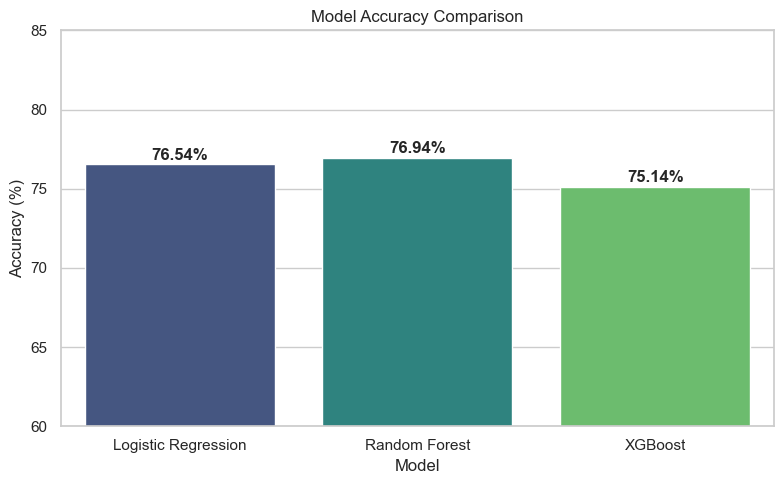

In [18]:
# Model Comparison Chart
plt.figure(figsize=(8, 5))
model_names = list(results.keys())
accuracies = [v * 100 for v in results.values()]
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(60, 85)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## SHAP Explainability

SHAP (SHapley Additive exPlanations) helps us understand which features drive the model's predictions — making the model interpretable for business stakeholders.

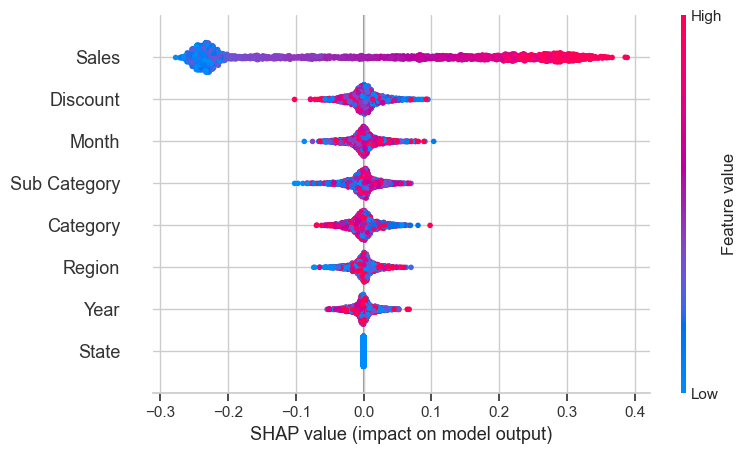

In [20]:
import shap

# Use Random Forest as best model
best_model = models['Random Forest']

# SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — use index 1 for positive class
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X.columns.tolist())

## Final Conclusion

Random Forest achieved the best accuracy at 76.94% in predicting whether a grocery order falls in the top 25% of profit. SHAP analysis reveals that Sales amount is the dominant driver of high profit orders, followed by Discount rate and seasonality (Month). Category and Region have moderate influence, confirming our EDA findings that the North region and Beverages sub-categories are the strongest profit contributors.